In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)

PATH = "C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/attainable_demand_baseline_p147_mar.csv"

df = pd.read_csv(PATH, encoding="utf-8-sig")
df["Дата"] = pd.to_datetime(df["Дата"])

print(df.shape)
df.head()

(2764, 31)


,Дата,Пекарня,Категория,Номенклатура,sku_sales_total,bakery_sales_total,good_execution_day,availability_score,stockout_like_hours,zero_under_traffic_hours,early_stop_flag,Продано,ДеньНедели,bakery_sales_total_calc,category_sales_total,share_of_bakery,share_of_category,final_expected_share,share_source_primary,blend_confidence_score,share_bakery_sku,share_sku_global,share_bakery_category,share_category_global,attainable_sales_from_bakery,attainable_sales_from_category,attainable_sales_baseline,attainable_gap,attainable_uplift_pct,opportunity_flag,opportunity_type
0,2026-03-17,Проспект Победы 147 Казань,Соки Морсы,Pulpy Ананас Манго,1.0,759.3,True,0.926667,1,4,False,1.0,1.0,759.3,14.0,0.001317,0.071429,0.109646,bakery_category,0.662091,0.001317,0.001317,0.119144,0.119144,83.254308,1.535046,1.535046,0.535046,53.504585,False,none
1,2026-03-31,Проспект Победы 147 Казань,Соки Морсы,Pulpy Ананас Манго,2.0,895.9,False,0.873333,3,5,False,2.0,1.0,895.9,30.0,0.002232,0.066667,0.109646,bakery_category,0.662091,0.001317,0.001317,0.119144,0.119144,98.231970,3.289384,3.289384,1.289384,64.469198,True,stockout_like
2,2026-03-13,Проспект Победы 147 Казань,Соки Морсы,Pulpy Апельсин,1.0,897.9,True,0.933333,2,2,False,1.0,4.0,897.9,8.0,0.001114,0.125000,0.107053,bakery_category,0.661254,0.001114,0.001114,0.115646,0.115646,96.122840,0.856424,1.000000,0.000000,0.000000,False,none
3,2026-03-14,Проспект Победы 147 Казань,Соки Морсы,Pulpy Апельсин,1.0,751.8,True,0.900000,2,4,False,1.0,5.0,751.8,6.0,0.001330,0.166667,0.106619,bakery_category,0.669267,0.001412,0.001412,0.120370,0.120370,80.155856,0.639712,1.000000,0.000000,0.000000,False,none
4,2026-03-18,Проспект Победы 147 Казань,Соки Морсы,Pulpy Апельсин,2.0,773.6,True,0.893333,2,5,False,2.0,2.0,773.6,13.0,0.002585,0.153846,0.105550,bakery_category,0.666809,0.001875,0.001875,0.117179,0.117179,81.653767,1.372155,2.000000,0.000000,0.000000,False,none


In [3]:
print("rows:", len(df))
print("rows_with_profiles:", df["final_expected_share"].notna().sum())
print("opportunity_rows:", df["opportunity_flag"].sum())
print("\nshare_source_primary")
print(df["share_source_primary"].value_counts(dropna=False))

print("\nopportunity_type")
print(df["opportunity_type"].value_counts(dropna=False))

print("\nattainable_gap describe")
print(df["attainable_gap"].describe())

rows: 2764
rows_with_profiles: 1647
opportunity_rows: 165

share_source_primary
share_source_primary
bakery_category    1631
NaN                1117
sku_global           16
Name: count, dtype: int64

opportunity_type
opportunity_type
none             2599
stockout_like     138
early_stop         27
Name: count, dtype: int64

attainable_gap describe
count    2764.000000
mean        2.275738
std        20.364616
min         0.000000
25%         0.000000
50%         0.000000
75%         0.097152
max       349.234357
Name: attainable_gap, dtype: float64


In [4]:
sku_summary = (
    df.groupby("Номенклатура", as_index=False)
    .agg(
        days=("Дата", "nunique"),
        observed_sales=("sku_sales_total", "sum"),
        attainable_sales=("attainable_sales_baseline", "sum"),
        total_gap=("attainable_gap", "sum"),
        mean_gap=("attainable_gap", "mean"),
        opportunity_days=("opportunity_flag", "sum"),
        mean_confidence=("blend_confidence_score", "mean"),
    )
    .sort_values("total_gap", ascending=False)
)

sku_summary.head(30)

,Номенклатура,days,observed_sales,attainable_sales,total_gap,mean_gap,opportunity_days,mean_confidence
93,Пакет спасибо,23,1075.5,5281.469548,4205.969548,182.868241,1,0.711858
62,Киш грибы курица,20,134.0,417.405279,283.405279,14.170264,9,0.497669
107,Пирожок зеленый лук,20,121.0,340.433566,219.433566,10.971678,7,0.503022
92,Пакет звезды,21,50.0,264.574684,214.574684,10.217842,4,0.360743
155,Тесто дрожжевое,16,38.6,245.676982,207.076982,12.942311,5,0.424945
68,Конвертик курица,21,116.0,289.003029,173.003029,8.238239,7,0.348439
108,Пирожок с горбушей,22,110.0,213.981258,103.981258,4.726421,5,0.275614
148,"Стакан 0,2",5,17.0,90.096865,73.096865,14.619373,1,0.537716
39,Жар пицца с курицей,23,494.0,565.053516,71.053516,3.089283,7,0.287375
158,Треугольник острый,22,427.0,488.423545,61.423545,2.791979,5,0.209868


In [5]:
cols = [
    "Дата",
    "Номенклатура",
    "sku_sales_total",
    "category_sales_total",
    "final_expected_share",
    "attainable_sales_baseline",
    "attainable_gap",
    "share_source_primary",
    "blend_confidence_score",
    "good_execution_day",
    "early_stop_flag",
    "stockout_like_hours",
    "opportunity_type",
]

df[cols].sort_values("attainable_gap", ascending=False).head(50)

,Дата,Номенклатура,sku_sales_total,category_sales_total,final_expected_share,attainable_sales_baseline,attainable_gap,share_source_primary,blend_confidence_score,good_execution_day,early_stop_flag,stockout_like_hours,opportunity_type
1412,2026-03-27,Пакет спасибо,44.0,49.0,0.443331,393.234357,349.234357,sku_global,0.714191,True,False,2,none
1398,2026-03-13,Пакет спасибо,69.0,72.5,0.443331,398.066662,329.066662,sku_global,0.714191,True,False,1,none
1410,2026-03-25,Пакет спасибо,44.0,54.5,0.381269,327.204955,283.204955,sku_global,0.714879,True,False,2,none
1415,2026-03-30,Пакет спасибо,56.0,69.0,0.402334,336.471546,280.471546,sku_global,0.719121,True,False,1,none
1416,2026-03-31,Пакет спасибо,60.0,74.5,0.378713,339.288600,279.288600,sku_global,0.714030,True,False,1,none
1409,2026-03-24,Пакет спасибо,44.0,53.0,0.378713,314.937382,270.937382,sku_global,0.714030,True,False,1,none
1411,2026-03-26,Пакет спасибо,49.0,50.0,0.366131,319.083105,270.083105,sku_global,0.713234,True,False,2,none
1401,2026-03-16,Пакет спасибо,54.0,57.0,0.402334,318.728636,264.728636,sku_global,0.719121,True,False,0,none
1408,2026-03-23,Пакет спасибо,48.0,61.0,0.402334,311.084299,263.084299,sku_global,0.719121,True,False,2,none
1403,2026-03-18,Пакет спасибо,38.0,41.0,0.381269,294.949608,256.949608,sku_global,0.714879,False,False,3,stockout_like


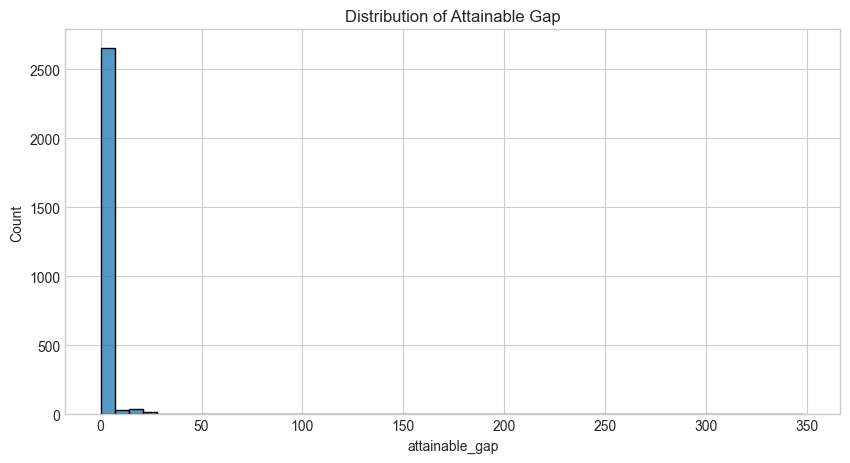

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df["attainable_gap"], bins=50)
plt.title("Distribution of Attainable Gap")
plt.xlabel("attainable_gap")
plt.ylabel("Count")
plt.show()

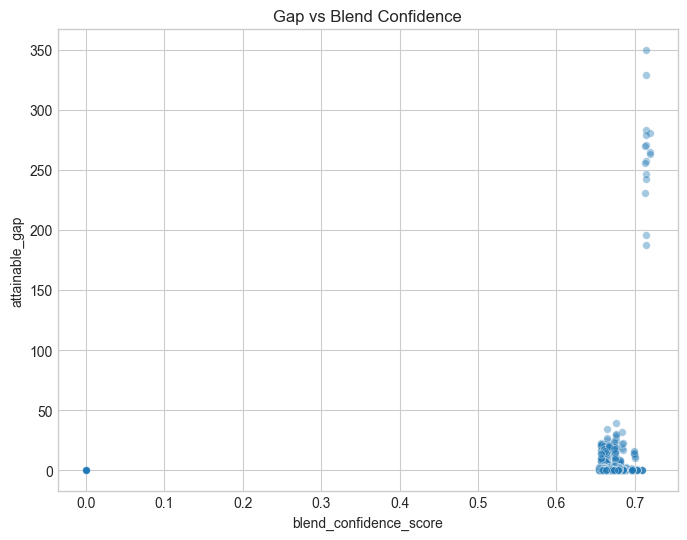

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="blend_confidence_score",
    y="attainable_gap",
    alpha=0.4,
    s=30
)
plt.title("Gap vs Blend Confidence")
plt.xlabel("blend_confidence_score")
plt.ylabel("attainable_gap")
plt.show()

In [8]:
top_skus = sku_summary.head(10)["Номенклатура"].tolist()
top_skus

['Пакет спасибо',
 'Киш грибы курица',
 'Пирожок зеленый лук',
 'Пакет звезды',
 'Тесто дрожжевое',
 'Конвертик курица',
 'Пирожок с горбушей',
 'Стакан 0,2',
 'Жар пицца с курицей',
 'Треугольник острый']

In [10]:
def plot_sku_timeseries(sku_name, data=df):
    sub = data[data["Номенклатура"] == sku_name].copy().sort_values("Дата")
    if sub.empty:
        print("No data for SKU:", sku_name)
        return

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(sub["Дата"], sub["sku_sales_total"], marker="o", label="Observed sales")
    ax.plot(sub["Дата"], sub["attainable_sales_baseline"], marker="s", linestyle="--", label="Attainable baseline")

    opp = sub[sub["opportunity_flag"] == True]
    if not opp.empty:
        ax.scatter(
            opp["Дата"],
            opp["attainable_sales_baseline"],
            color="red",
            s=80,
            label="Opportunity",
            zorder=5,
        )

    ax.set_title(sku_name)
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display_cols = [
        "Дата",
        "sku_sales_total",
        "attainable_sales_baseline",
        "attainable_gap",
        "share_source_primary",
        "blend_confidence_score",
        "good_execution_day",
        "early_stop_flag",
        "stockout_like_hours",
        "opportunity_type",
    ]
    display(sub[display_cols].tail(20))

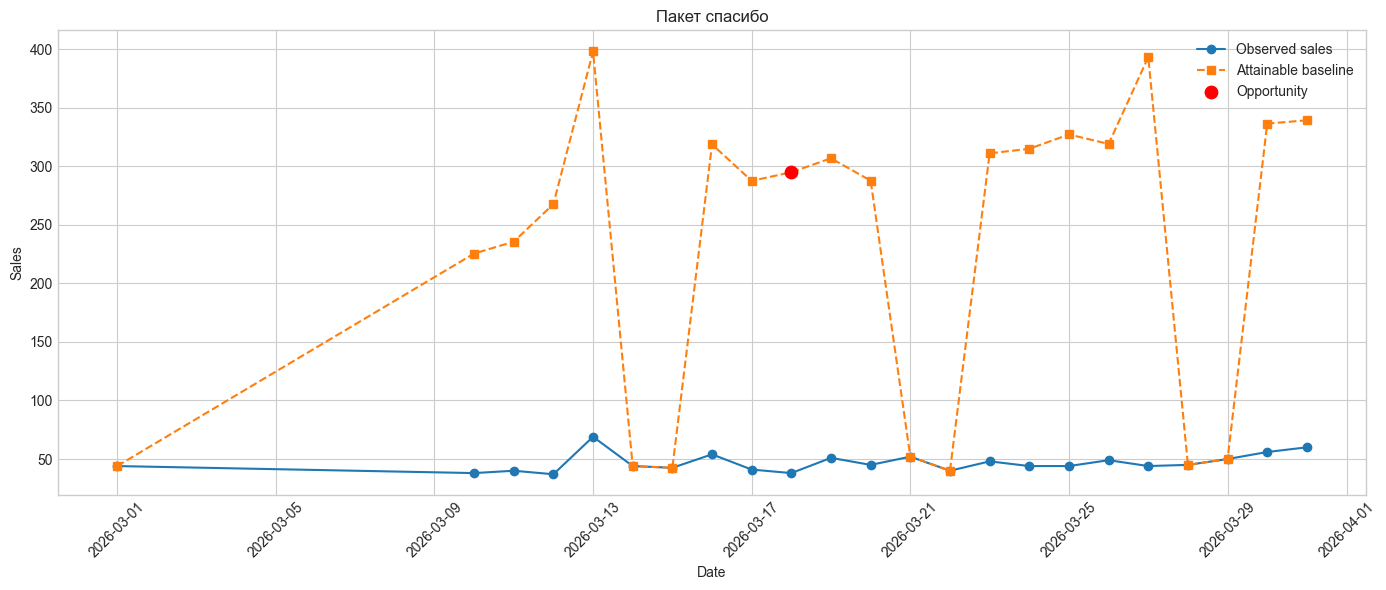

,Дата,sku_sales_total,attainable_sales_baseline,attainable_gap,share_source_primary,blend_confidence_score,good_execution_day,early_stop_flag,stockout_like_hours,opportunity_type
1397,2026-03-12,37.0,267.714935,230.714935,sku_global,0.713234,True,False,0,none
1398,2026-03-13,69.0,398.066662,329.066662,sku_global,0.714191,True,False,1,none
1399,2026-03-14,44.0,44.000000,0.000000,bakery_category,0.697660,False,False,3,none
1400,2026-03-15,42.5,42.500000,0.000000,bakery_category,0.709838,True,False,1,none
1401,2026-03-16,54.0,318.728636,264.728636,sku_global,0.719121,True,False,0,none
1402,2026-03-17,41.0,287.556462,246.556462,sku_global,0.714030,True,False,2,none
1403,2026-03-18,38.0,294.949608,256.949608,sku_global,0.714879,False,False,3,stockout_like
1404,2026-03-19,51.0,306.817718,255.817718,sku_global,0.713234,True,False,1,none
1405,2026-03-20,45.0,287.721643,242.721643,sku_global,0.714191,True,False,1,none
1406,2026-03-21,52.0,52.000000,0.000000,bakery_category,0.697660,True,False,1,none


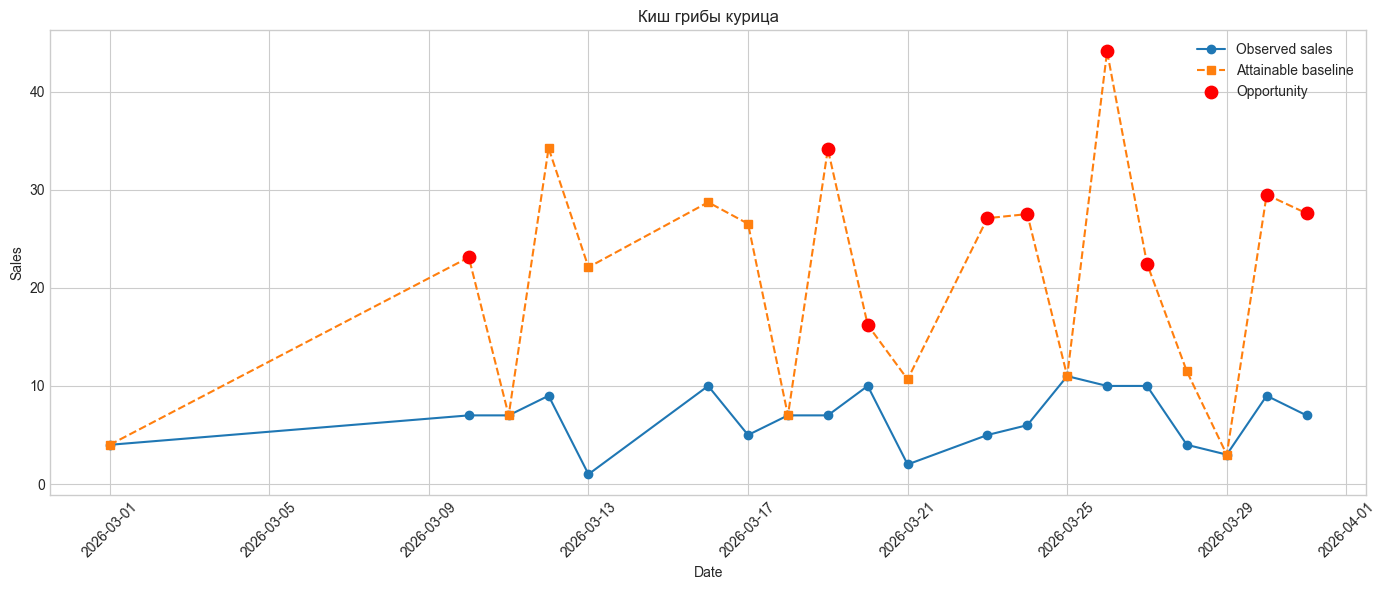

,Дата,sku_sales_total,attainable_sales_baseline,attainable_gap,share_source_primary,blend_confidence_score,good_execution_day,early_stop_flag,stockout_like_hours,opportunity_type
877,2026-03-01,4.0,4.000000,0.000000,NaN,0.000000,False,False,5,none
878,2026-03-10,7.0,23.105293,16.105293,bakery_category,0.657379,False,False,3,stockout_like
879,2026-03-11,7.0,7.000000,0.000000,NaN,0.000000,False,False,3,none
880,2026-03-12,9.0,34.232083,25.232083,bakery_category,0.664174,True,False,2,none
881,2026-03-13,1.0,22.095371,21.095371,bakery_category,0.664722,True,False,1,none
882,2026-03-16,10.0,28.718026,18.718026,bakery_category,0.662526,True,False,2,none
883,2026-03-17,5.0,26.525484,21.525484,bakery_category,0.657379,True,False,2,none
884,2026-03-18,7.0,7.000000,0.000000,NaN,0.000000,False,False,7,none
885,2026-03-19,7.0,34.132571,27.132571,bakery_category,0.664174,False,False,5,stockout_like
886,2026-03-20,10.0,16.211618,6.211618,bakery_category,0.664722,False,True,2,early_stop


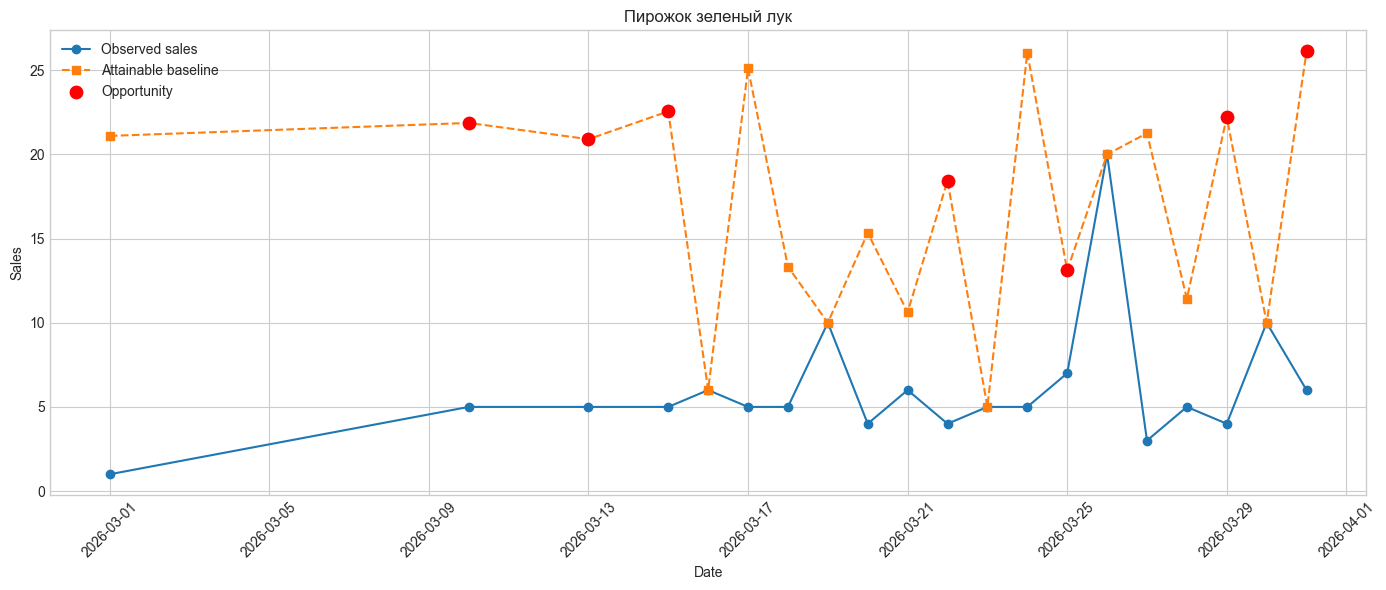

,Дата,sku_sales_total,attainable_sales_baseline,attainable_gap,share_source_primary,blend_confidence_score,good_execution_day,early_stop_flag,stockout_like_hours,opportunity_type
1574,2026-03-01,1.0,21.098009,20.098009,bakery_category,0.660773,True,False,1,none
1575,2026-03-10,5.0,21.868988,16.868988,bakery_category,0.667414,False,False,4,stockout_like
1576,2026-03-13,5.0,20.902425,15.902425,bakery_category,0.676017,False,False,4,stockout_like
1577,2026-03-15,5.0,22.556001,17.556001,bakery_category,0.660773,False,True,2,early_stop
1578,2026-03-16,6.0,6.000000,0.000000,NaN,0.000000,False,False,5,none
1579,2026-03-17,5.0,25.106174,20.106174,bakery_category,0.667414,True,False,2,none
1580,2026-03-18,5.0,13.332145,8.332145,bakery_category,0.681922,True,False,2,none
1581,2026-03-19,10.0,10.000000,0.000000,NaN,0.000000,False,False,4,none
1582,2026-03-20,4.0,15.336340,11.336340,bakery_category,0.676017,True,False,2,none
1583,2026-03-21,6.0,10.624681,4.624681,bakery_category,0.677897,True,False,2,none


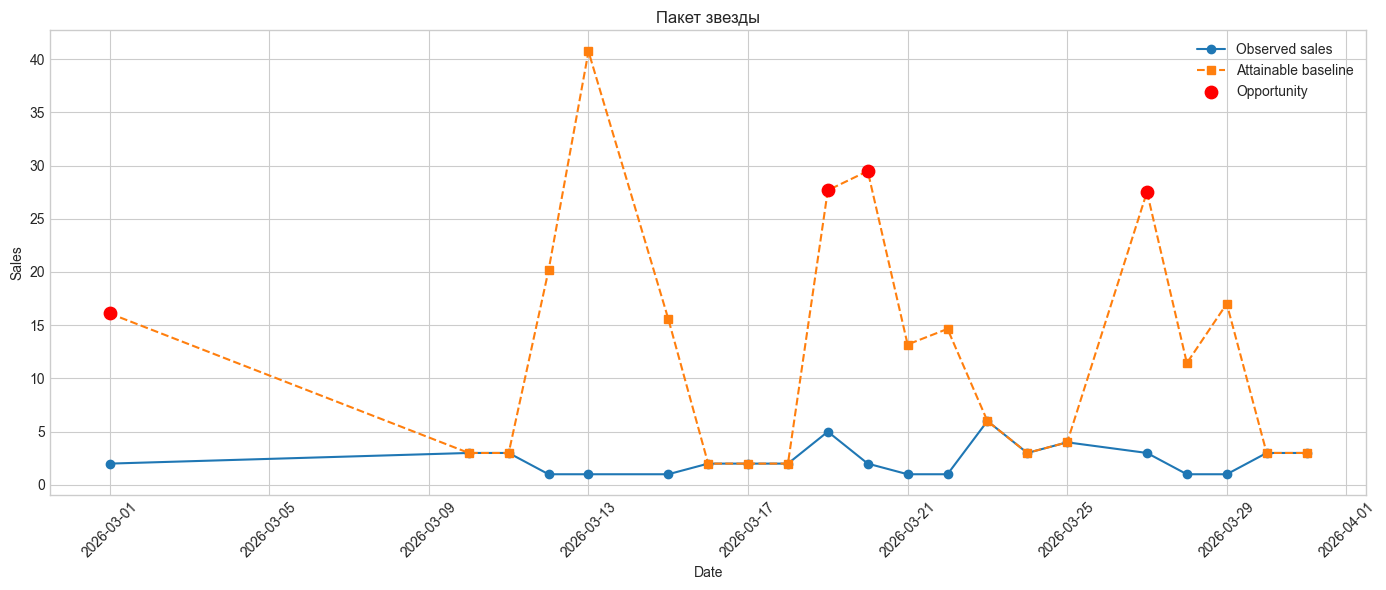

,Дата,sku_sales_total,attainable_sales_baseline,attainable_gap,share_source_primary,blend_confidence_score,good_execution_day,early_stop_flag,stockout_like_hours,opportunity_type
1374,2026-03-10,3.0,3.000000,0.000000,NaN,0.000000,False,False,4,none
1375,2026-03-11,3.0,3.000000,0.000000,NaN,0.000000,False,False,3,none
1376,2026-03-12,1.0,20.170024,19.170024,bakery_category,0.673463,True,False,2,none
1377,2026-03-13,1.0,40.716228,39.716228,bakery_category,0.676188,True,False,2,none
1378,2026-03-15,1.0,15.599910,14.599910,bakery_category,0.699652,True,False,2,none
1379,2026-03-16,2.0,2.000000,0.000000,NaN,0.000000,False,False,4,none
1380,2026-03-17,2.0,2.000000,0.000000,NaN,0.000000,False,False,3,none
1381,2026-03-18,2.0,2.000000,0.000000,NaN,0.000000,False,False,4,none
1382,2026-03-19,5.0,27.675149,22.675149,bakery_category,0.673463,False,False,6,stockout_like
1383,2026-03-20,2.0,29.484165,27.484165,bakery_category,0.676188,False,False,3,stockout_like


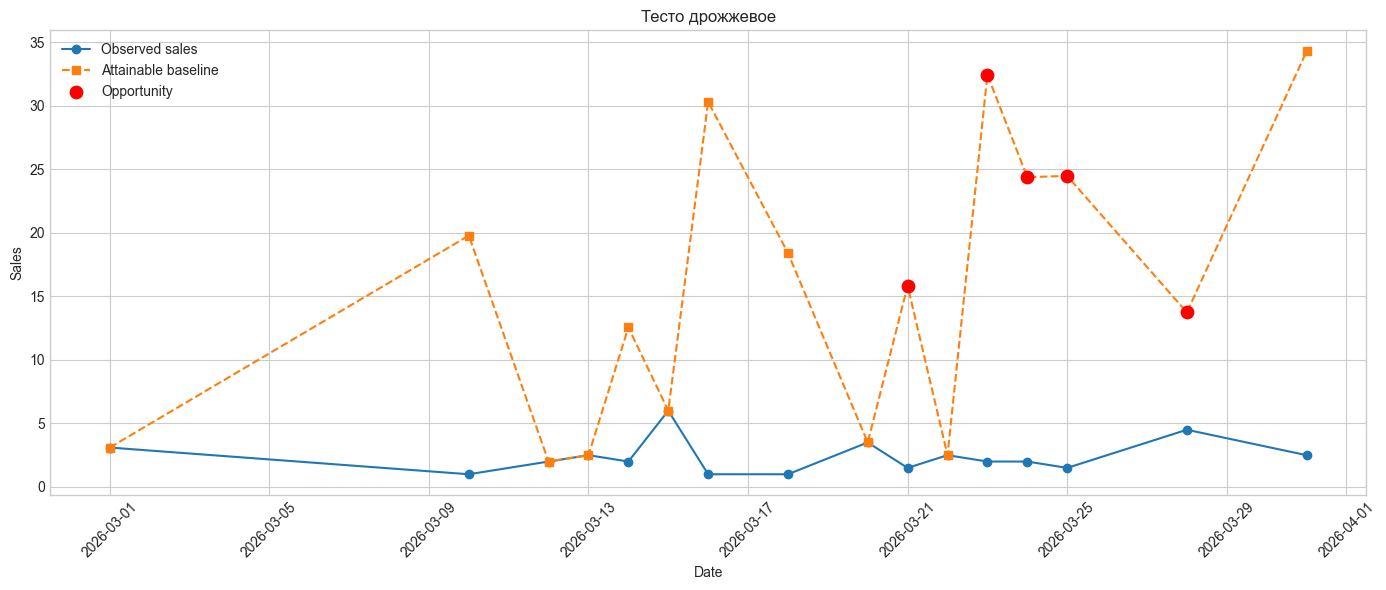

,Дата,sku_sales_total,attainable_sales_baseline,attainable_gap,share_source_primary,blend_confidence_score,good_execution_day,early_stop_flag,stockout_like_hours,opportunity_type
2319,2026-03-01,3.1,3.100000,0.000000,NaN,0.000000,False,False,5,none
2320,2026-03-10,1.0,19.771457,18.771457,bakery_category,0.684192,True,False,0,none
2321,2026-03-12,2.0,2.000000,0.000000,NaN,0.000000,False,False,4,none
2322,2026-03-13,2.5,2.500000,0.000000,NaN,0.000000,False,False,4,none
2323,2026-03-14,2.0,12.552787,10.552787,bakery_category,0.674786,True,False,2,none
2324,2026-03-15,6.0,6.000000,0.000000,NaN,0.000000,False,True,2,none
2325,2026-03-16,1.0,30.289013,29.289013,bakery_category,0.675672,True,False,2,none
2326,2026-03-18,1.0,18.406272,17.406272,bakery_category,0.685422,True,False,2,none
2327,2026-03-20,3.5,3.500000,0.000000,NaN,0.000000,False,False,5,none
2328,2026-03-21,1.5,15.821742,14.321742,bakery_category,0.674786,False,False,3,stockout_like


In [11]:
for sku in top_skus[:5]:
      plot_sku_timeseries(sku)

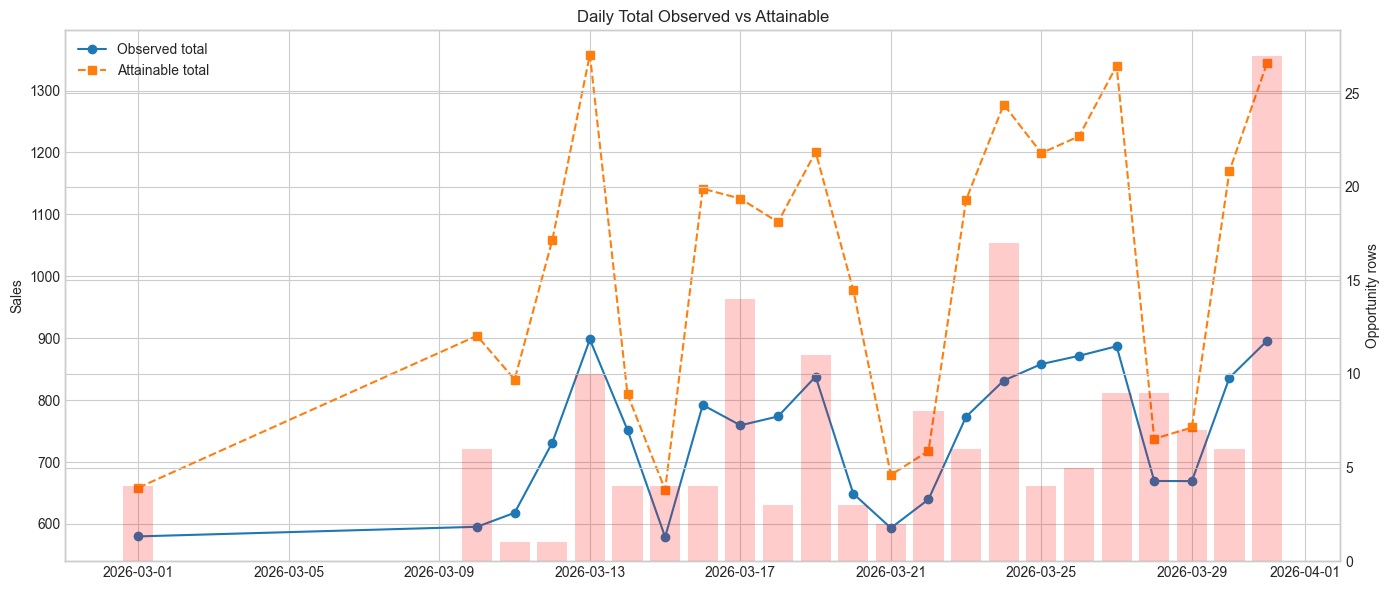

In [12]:
daily_summary = (
    df.groupby("Дата", as_index=False)
    .agg(
        observed_sales=("sku_sales_total", "sum"),
        attainable_sales=("attainable_sales_baseline", "sum"),
        total_gap=("attainable_gap", "sum"),
        opportunity_rows=("opportunity_flag", "sum"),
    )
)

daily_summary

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(daily_summary["Дата"], daily_summary["observed_sales"], marker="o", label="Observed total")
ax1.plot(daily_summary["Дата"], daily_summary["attainable_sales"], marker="s", linestyle="--", label="Attainable total")
ax1.set_ylabel("Sales")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.bar(daily_summary["Дата"], daily_summary["opportunity_rows"], alpha=0.2, color="red", label="Opportunity rows")
ax2.set_ylabel("Opportunity rows")

plt.title("Daily Total Observed vs Attainable")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

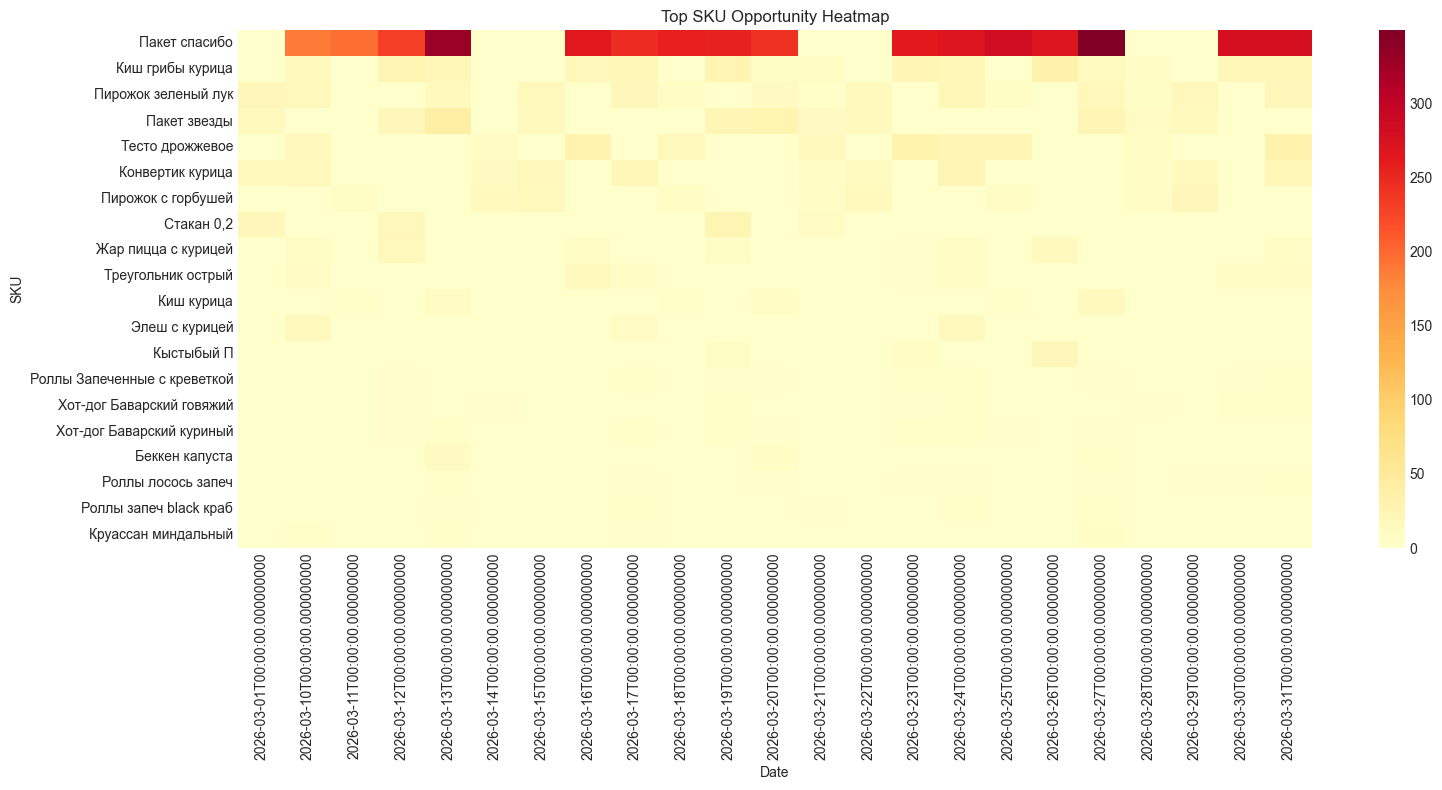

In [13]:
heat = df.pivot_table(
    index="Номенклатура",
    columns="Дата",
    values="attainable_gap",
    aggfunc="sum",
    fill_value=0,
)

top_heat = heat.loc[sku_summary.head(20)["Номенклатура"]]

plt.figure(figsize=(16, 8))
sns.heatmap(top_heat, cmap="YlOrRd")
plt.title("Top SKU Opportunity Heatmap")
plt.xlabel("Date")
plt.ylabel("SKU")
plt.tight_layout()
plt.show()